<a href="https://colab.research.google.com/github/leeobazzana01/Mobile-Market-Share-/blob/main/mobile_market_share_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobile Market Share 2026

## Engenharia de Aplicações Móveis - Docente: Will Machado

---

## Introdução

O presente dataset, elaborado pelos alunos **Leonardo José Bazana Lima, Pedro Paulo Fontelles Tooda e Vinicius Henrique Muniz**, propõe **responder questões relacionadas ao desenvolvimento mobile de software** no Mercado de 2026, apontando as principais tendências considerando o impacto na adoção Grandes Modelos de Linguagem (LLMs) e ferramentas de Inteligência Artificial para a **Engenharia de Aplicações Móveis**.  

---


### 1) Pesquise em 2 fontes confiáveis (stackoverflow, Gartner, Microsoft, IBM, ...) **quais linguagens**(plataformas) de programação mobile tem sido mais usada pelo mercado nos anos de 2025, 2024 e 2023, no Brasil, nos EUA, na Europa e na Ásia. Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



Consideramos como fonte o **stackoverflow developer survey** nos anos de 2023, 2024 e 2025 para uma **Análise Exploratória de Dados Robusta**, apontando tendências globais no mercado de desenvolvimento mobile.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from google.colab import userdata
from pathlib import Path
import seaborn as sns
import warnings
import logging

In [ ]:


#baixando datasets
!kaggle datasets download -d stackoverflow/stack-overflow-2023-developers-survey #2023 survey
!kaggle datasets download -d ijnskjet/2024-stack-overflow-annual-developer-survey #2024
!kaggle datasets download -d edoardogalli/stack-overflow-annual-developer-survey-2025 #2025



Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stack-overflow-2023-developers-survey
License(s): unknown
100% 20.5M/20.5M [00:01<00:00, 19.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/ijnskjet/2024-stack-overflow-annual-developer-survey
License(s): EU ODP Legal Notice
100% 16.9M/16.9M [00:01<00:00, 17.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025
License(s): ODbL-1.0
100% 16.9M/16.9M [00:01<00:00, 17.5MB/s]



In [ ]:
#criando uma lista de arquivos a serem extraídos
arquivos_kaggle_survey = [
  '2024-stack-overflow-annual-developer-survey.zip',
  'stack-overflow-2023-developers-survey.zip',
  'stack-overflow-annual-developer-survey-2025.zip']

#extraindo os arquivos .zip para uma pasta específica
pasta_destino_raiz = '/content/datasets_extraidos'

for arquivo in arquivos_kaggle_survey:

    nome_pasta = Path(arquivo).stem

    #criando o caminho final
    caminho_final_extracao = os.path.join(pasta_destino_raiz, nome_pasta)

    #criando a pasta caso nao existir
    os.makedirs(caminho_final_extracao, exist_ok=True)

    print(f"Extraindo {arquivo} para {caminho_final_extracao}...")

    with zipfile.ZipFile(arquivo, 'r') as zip_ref:
        #caminho da pasta específica criada como argumento
        zip_ref.extractall(caminho_final_extracao)

    print(f"Extração concluída. Removendo arquivo original...")

    os.remove(arquivo)
    print(f"Arquivo removido: {arquivo}\n")

print("Sucesso: datasets organizados, extraídos e dados compactados removidos!")

Extraindo 2024-stack-overflow-annual-developer-survey.zip para /content/datasets_extraidos/2024-stack-overflow-annual-developer-survey...
Extração concluída. Removendo arquivo original...
Arquivo removido: 2024-stack-overflow-annual-developer-survey.zip

Extraindo stack-overflow-2023-developers-survey.zip para /content/datasets_extraidos/stack-overflow-2023-developers-survey...
Extração concluída. Removendo arquivo original...
Arquivo removido: stack-overflow-2023-developers-survey.zip

Extraindo stack-overflow-annual-developer-survey-2025.zip para /content/datasets_extraidos/stack-overflow-annual-developer-survey-2025...
Extração concluída. Removendo arquivo original...
Arquivo removido: stack-overflow-annual-developer-survey-2025.zip

Sucesso: datasets organizados, extraídos e dados compactados removidos!


In [48]:
#ocultando avisos do Python (Pandas/Seaborn)
warnings.filterwarnings('ignore')

#ocultando avisos do country_converter
logging.getLogger('country_converter').setLevel(logging.ERROR)

In [ ]:
#lendo dados e criando dataframes
df_survey_2023 = pd.read_csv('/content/datasets_extraidos/stack-overflow-2023-developers-survey/survey_results_public.csv')
df_survey_2024 = pd.read_csv('/content/datasets_extraidos/2024-stack-overflow-annual-developer-survey/survey_results_public.csv')
df_survey_2025 = pd.read_csv('/content/datasets_extraidos/stack-overflow-annual-developer-survey-2025/survey_results_public.csv')

#criando copias

df_2023 = df_survey_2023.copy()
df_2024 = df_survey_2024.copy()
df_2025 = df_survey_2025.copy()

In [ ]:
#criando um novo dataframe de 2023 apenas com as características relevantes
colunas_desejadas_2023 = ['Employment', 'YearsCode', 'DevType', 'OrgSize', 'Country', 'ProfessionalTech', 'Industry', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'ToolsTechHaveWorkedWith', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackSyncHaveWorkedWith', 'AIToolCurrently Using']

df_23 = df_2023[colunas_desejadas_2023]

df_23.head()

,Employment,YearsCode,DevType,OrgSize,Country,ProfessionalTech,Industry,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OfficeStackAsyncHaveWorkedWith,OfficeStackSyncHaveWorkedWith,AIToolCurrently Using
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Employed, full-time",18,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,United States of America,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",HTML/CSS;JavaScript;Python,Supabase,Amazon Web Services (AWS);Netlify;Vercel,Next.js;React;Remix;Vue.js,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,Asana;Basecamp;GitHub Discussions;Jira;Linear;...,Cisco Webex Teams;Discord;Google Chat;Google M...,Writing code;Committing and reviewing code
2,"Employed, full-time",27,"Developer, back-end","5,000 to 9,999 employees",United States of America,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Bash/Shell (all shells);Go,NaN,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,Cargo;Docker;Kubernetes;Make;Nix,Markdown File;Stack Overflow for Teams,Microsoft Teams;Slack;Zoom,NaN
3,"Employed, full-time",12,"Developer, front-end",100 to 499 employees,United States of America,Automated testing;Continuous integration (CI) ...,NaN,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,PostgreSQL;Redis,Cloudflare;Heroku,Node.js;React;Ruby on Rails;Vue.js;WordPress,Homebrew;npm;Vite;Webpack;Yarn,Jira,Discord;Google Meet;Microsoft Teams;Slack;Zoom,NaN
4,"Employed, full-time;Independent contractor, fr...",6,"Developer, full-stack",20 to 99 employees,Philippines,Microservices;Automated testing;Observability ...,Other,HTML/CSS;JavaScript;TypeScript,BigQuery;Elasticsearch;MongoDB;PostgreSQL,Amazon Web Services (AWS);Firebase;Heroku;Netl...,Express;Gatsby;NestJS;Next.js;Node.js;React,Docker;npm;Webpack;Yarn,Confluence;Jira;Notion,Discord;Google Meet;Slack;Zoom,Learning about a codebase;Writing code;Documen...


In [ ]:
#analisando todas as categorias presentes no dataset
contagem_devtype_23 = df_23['DevType'].value_counts()

print(contagem_devtype_23)


DevType
Developer, full-stack                            25735
Developer, back-end                              13745
Developer, front-end                              5071
Developer, desktop or enterprise applications     3904
Other (please specify):                           3080
Developer, mobile                                 2597
Engineering manager                               2033
Student                                           1996
Developer, embedded applications or devices       1845
Data scientist or machine learning specialist     1588
DevOps specialist                                 1387
Academic researcher                               1354
Research & Development role                       1353
Senior Executive (C-Suite, VP, etc.)              1332
Engineer, data                                    1248
Cloud infrastructure engineer                     1036
Developer, game or graphics                        866
Data or business analyst                           837
Sy

In [ ]:
#filtrando apenas os desenvolvedores mobile
df_mobile_23 = df_23[df_23['DevType'].str.contains('Developer, mobile', na=False)].copy()

df_mobile_23.head()

,Employment,YearsCode,DevType,OrgSize,Country,ProfessionalTech,Industry,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OfficeStackAsyncHaveWorkedWith,OfficeStackSyncHaveWorkedWith,AIToolCurrently Using
51,"Employed, full-time",4,"Developer, mobile",20 to 99 employees,Sri Lanka,Automated testing,Other,Swift,Firebase Realtime Database,NaN,NaN,NaN,NaN,Google Chat;Google Meet,Documenting code
54,"Employed, full-time",5,"Developer, mobile",I don’t know,Lebanon,NaN,NaN,Java;JavaScript;Kotlin;SQL;TypeScript,Firebase Realtime Database;Microsoft SQL Serve...,NaN,Node.js;React;Spring Boot,Dagger;Gradle;Maven (build tool),Confluence,Google Meet;Microsoft Teams;Slack;Zoom,NaN
176,"Employed, full-time",6,"Developer, mobile","Just me - I am a freelancer, sole proprietor, ...","Iran, Islamic Republic of...",DevOps function,Other,C;C++;Dart;Java;SQL,Microsoft SQL Server;MongoDB;MySQL;SQLite,Firebase;Google Cloud;VMware,NaN,CMake;Gradle,GitHub Discussions;Jira;Stack Overflow for Tea...,Discord;Google Meet;Skype;Slack;Telegram;Whatsapp,Project planning;Writing code;Debugging and ge...
177,"Employed, full-time",10,"Developer, mobile",20 to 99 employees,India,NaN,"Information Services, IT, Software Development...",Objective-C,SQLite,NaN,NaN,NaN,NaN,Microsoft Teams;Skype,NaN
179,"Employed, full-time;Student, full-time",5,"Developer, mobile",NaN,Lebanon,None of these,NaN,MATLAB;Swift,PostgreSQL,Digital Ocean;Google Cloud;Heroku;Microsoft Az...,NaN,Docker;Homebrew;LLVM's Clang,NaN,Google Meet;Microsoft Teams;Whatsapp;Zoom,NaN


In [49]:
#configurações globais de estilo visual EDA
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [50]:
def preparar_df_mobile(df: pd.DataFrame, ano: int) -> pd.DataFrame:
    #filtrando apenas os desenvolvedores mobile em cada dataset"
    df_copy = df.copy()

    #filtro de devs mobile
    if 'DevType' in df_copy.columns:
        mascara = df_copy['DevType'].astype(str).str.contains('mobile', case=False, na=False)
        df_copy = df_copy[mascara].copy()

    #mapeando os países e continentes
    if 'Country' in df_copy.columns and 'Continent' not in df_copy.columns:
        paises = df_copy['Country'].dropna().tolist()
        df_copy['Continent'] = 'Unknown'
        df_copy.loc[df_copy['Country'].notna(), 'Continent'] = coco.convert(
            names=paises, to='continent'
        )

    print(f"Dataset Mobile {ano} preparado. Total de registros: {len(df_copy)}")
    return df_copy

In [51]:
def plotar_distribuicao_continentes(df_mobile: pd.DataFrame, ano: int):
    #plotando a distribuuiçao total de desenvolvedores por continente
    distribuicao = df_mobile['Continent'].value_counts()

    plt.figure(figsize=(9, 5))
    distribuicao.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title(f'Stack Overflow Survey {ano} - Devs Mobile por Continente', fontsize=13, weight='bold')
    plt.xlabel('Continente', fontsize=11)
    plt.ylabel('Número de Desenvolvedores', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [52]:
def plotar_categoria_por_continente(
    df_mobile: pd.DataFrame,
    coluna: str,
    rotulo_eixo: str,
    titulo_categoria: str,
    ano: int,
    continentes: list = ['Europe', 'Asia', 'America'],
    top_n: int = 5
):
    """
    Função genérica que desmembra respostas multivaloradas, filtra continentes
    e plota o FacetGrid ordenado com o Top N por continente.
    """
    if coluna not in df_mobile.columns:
        print(f" Coluna '{coluna}' não encontrada para o ano {ano}.")
        return

    # Filtra continentes selecionados
    df_filtrado = df_mobile[df_mobile['Continent'].isin(continentes)].copy()

    # Desmembra valores separados por ';'
    df_explodido = (
        df_filtrado.assign(Item=df_filtrado[coluna].str.split(';'))
        .explode('Item')
        .dropna(subset=['Item'])
    )
    df_explodido['Item'] = df_explodido['Item'].str.strip()

    # Contagem e ordenação por continente
    tabela_freq = (
        df_explodido.groupby(['Continent', 'Item'])
        .size()
        .reset_index(name='Count')
    )

    top_por_continente = (
        tabela_freq.groupby('Continent', group_keys=False)
        .apply(lambda x: x.nlargest(top_n, 'Count'))
        .reset_index(drop=True)
    )

    # Plotagem via FacetGrid
    g = sns.FacetGrid(
        top_por_continente,
        col='Continent',
        sharey=False,
        height=4.5,
        aspect=1.2
    )
    g.map_dataframe(
        sns.barplot,
        x='Count',
        y='Item',
        palette='viridis',
        edgecolor='black'
    )

    g.set_axis_labels('Número de Desenvolvedores', rotulo_eixo)
    g.set_titles(col_template='Continente: {col_name}')
    g.fig.subplots_adjust(top=0.8)
    g.fig.suptitle(
        f'Stack Overflow Developer Survey {ano}\nTop {titulo_categoria} Mobile por Continente',
        fontsize=14,
        weight='bold'
    )
    plt.tight_layout()
    plt.show()

In [53]:
def plotar_top_pizza(df_mobile: pd.DataFrame, coluna: str, titulo: str, ano: int, top_n: int = 6):
    #gera um gráfico de pizza para o Top N global
    if coluna not in df_mobile.columns:
        print(f"Coluna '{coluna}' não encontrada para o ano {ano}.")
        return

    itens = df_mobile[coluna].dropna().str.split(';').explode().str.strip()
    top_itens = itens.value_counts().head(top_n)

    plt.figure(figsize=(7, 7))
    top_itens.plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        cmap='Set3',
        wedgeprops={'edgecolor': 'white'}
    )
    plt.title(f'Stack Overflow Survey {ano} - Top {top_n} {titulo}', fontsize=13, weight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()



In [54]:
#executando o pipleine completo

def executar_pipeline_completo(df_2023: pd.DataFrame, df_2024: pd.DataFrame, df_2025: pd.DataFrame):

    #dicionario com os dataframes a serem analisados
    raw_dfs = {2023: df_2023, 2024: df_2024, 2025: df_2025}

    mobile_dfs = {}

    #processa cada cada ano para o ecossistema Mobile
    for ano, df in raw_dfs.items():
        print(f"\n--- PROCESSANDO ANO {ano} ---")
        df_mob = preparar_df_mobile(df, ano)
        mobile_dfs[ano] = df_mob

        #visualizações por ano
        plotar_distribuicao_continentes(df_mob, ano)
        plotar_top_pizza(df_mob, 'LanguageHaveWorkedWith', 'Linguagens Mobile', ano)

        #analises por Continente
        plotar_categoria_por_continente(
            df_mob, 'LanguageHaveWorkedWith', 'Linguagem', 'Linguagens Mobile', ano
        )
        plotar_categoria_por_continente(
            df_mob, 'DatabaseHaveWorkedWith', 'Banco de Dados', 'Bancos de Dados Mobile', ano
        )
        plotar_categoria_por_continente(
            df_mob, 'PlatformHaveWorkedWith', 'Plataforma', 'Plataformas de Nuvem Mobile', ano
        )

        #coluna de Frameworks (muda em 2025/2024/2023)
        col_fw = 'WebframeHaveWorkedWith' if 'WebframeHaveWorkedWith' in df_mob.columns else 'MiscTechHaveWorkedWith'
        plotar_categoria_por_continente(
            df_mob, col_fw, 'Framework', 'Frameworks Mobile', ano
        )



--- PROCESSANDO ANO 2023 ---
Dataset Mobile 2023 preparado. Total de registros: 2597


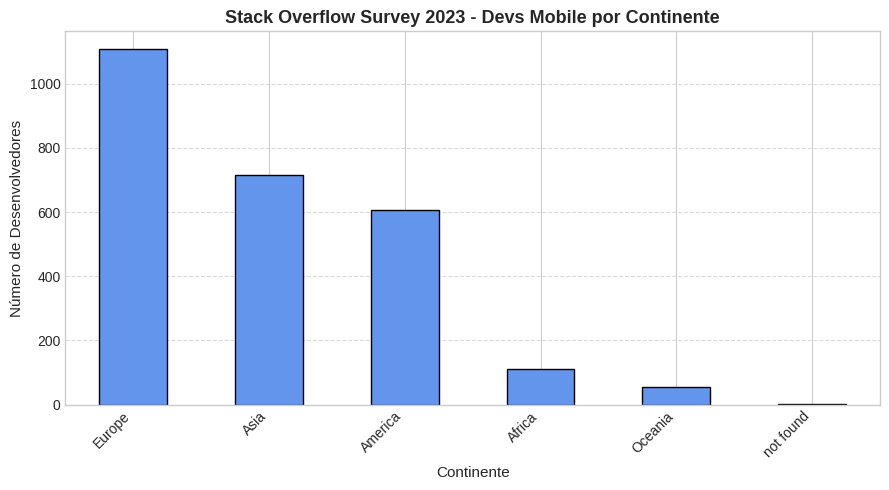

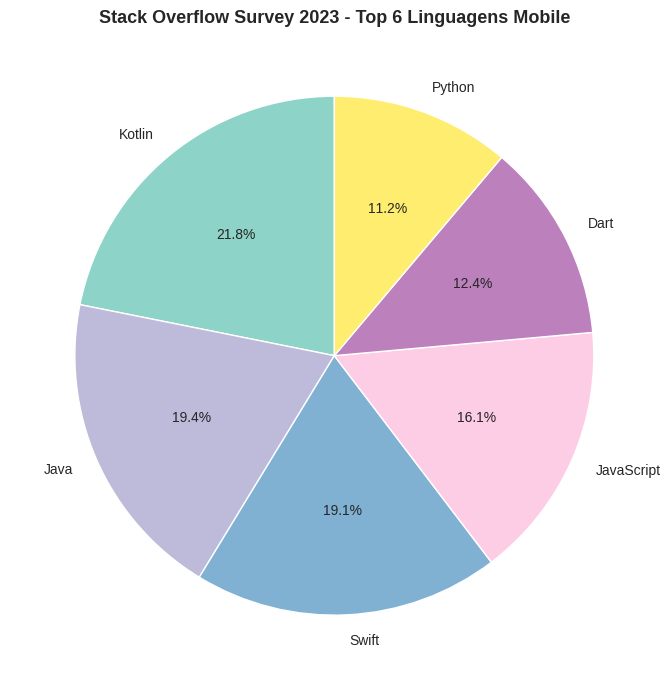

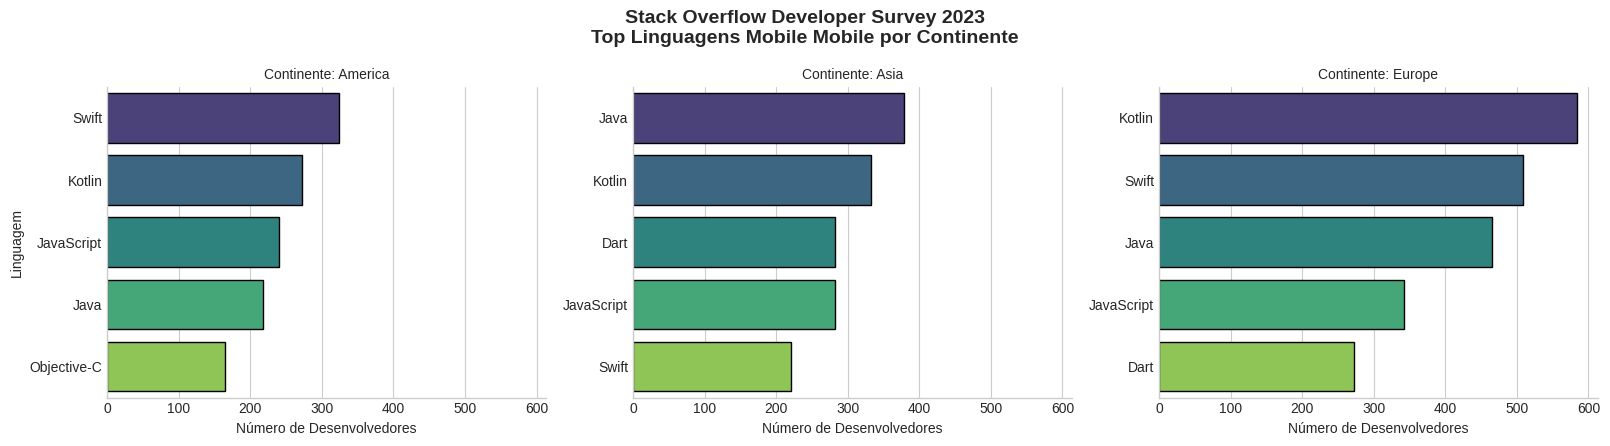

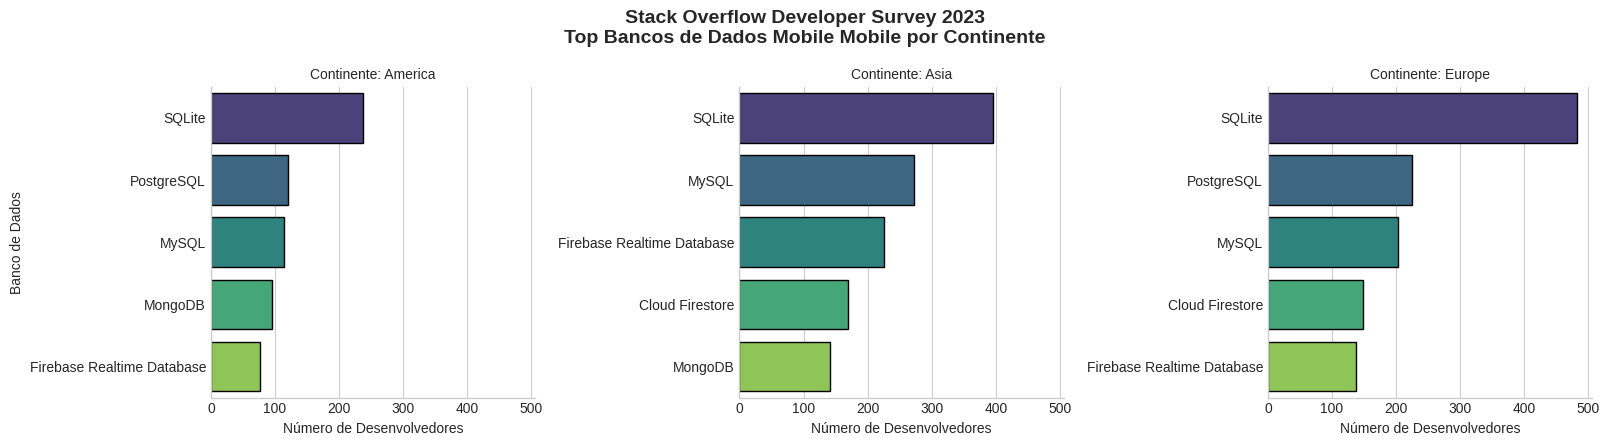

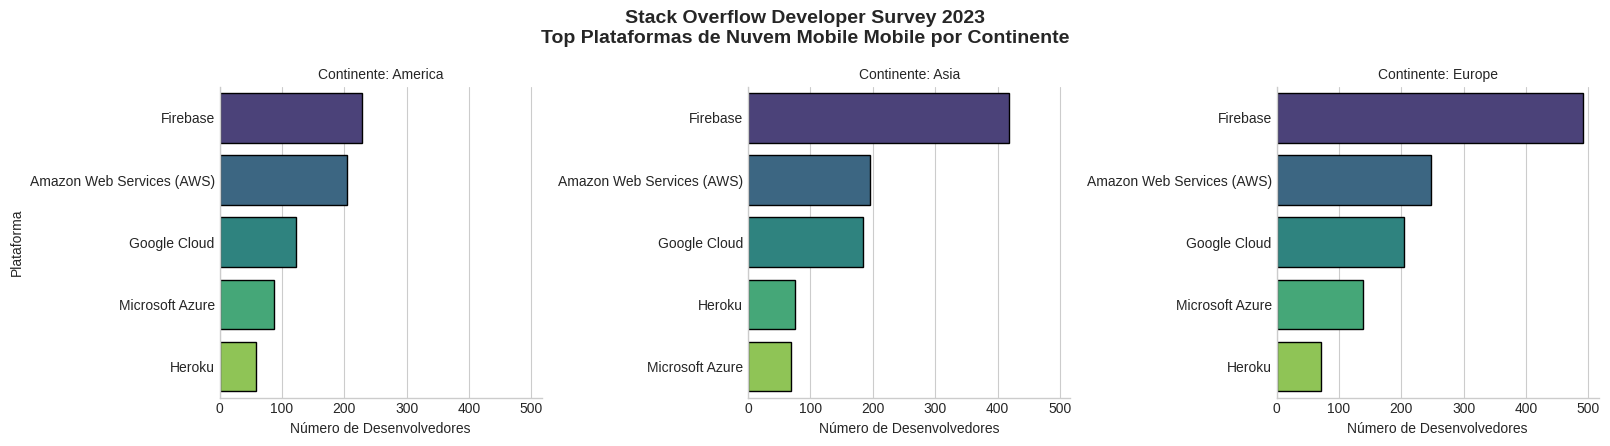

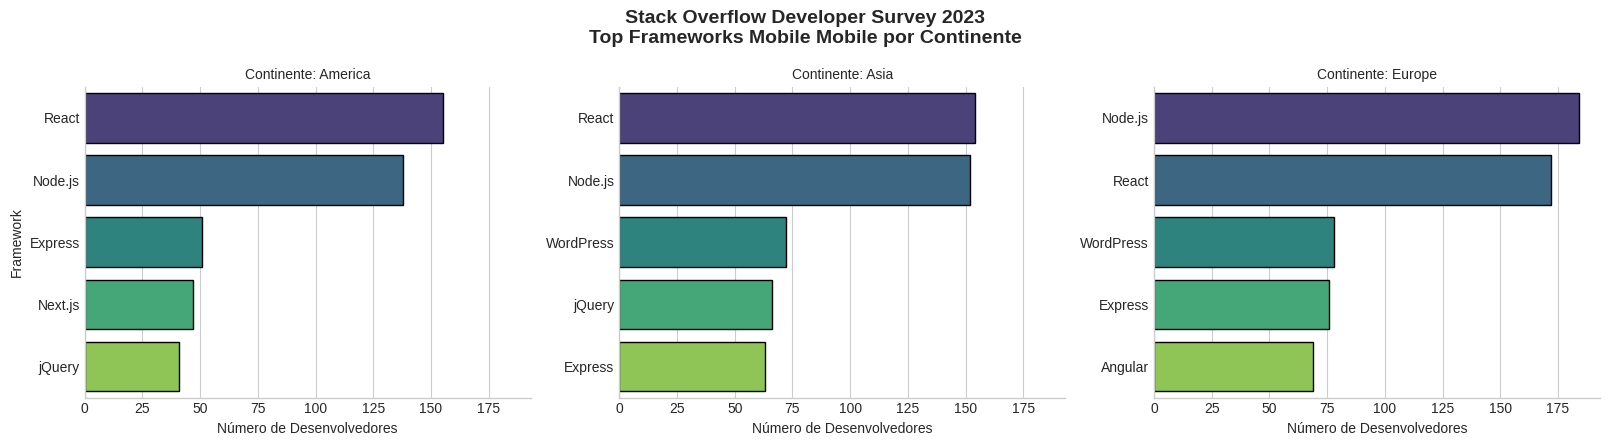


--- PROCESSANDO ANO 2024 ---
Dataset Mobile 2024 preparado. Total de registros: 2021


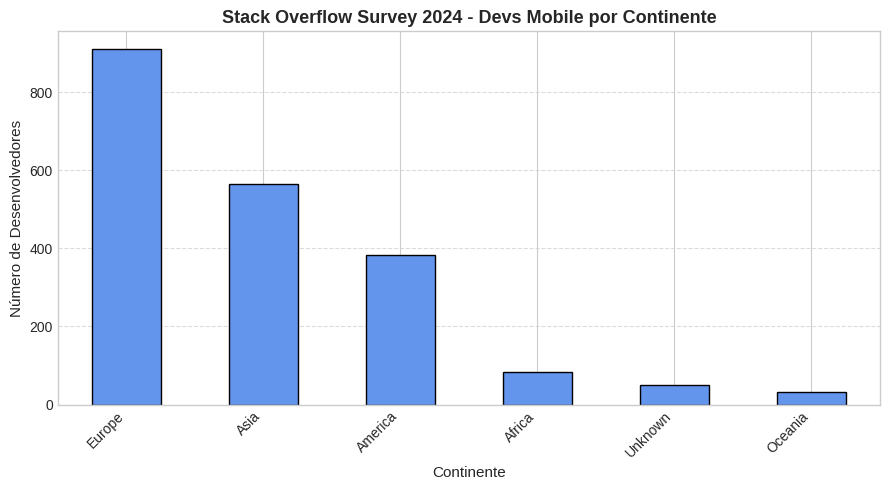

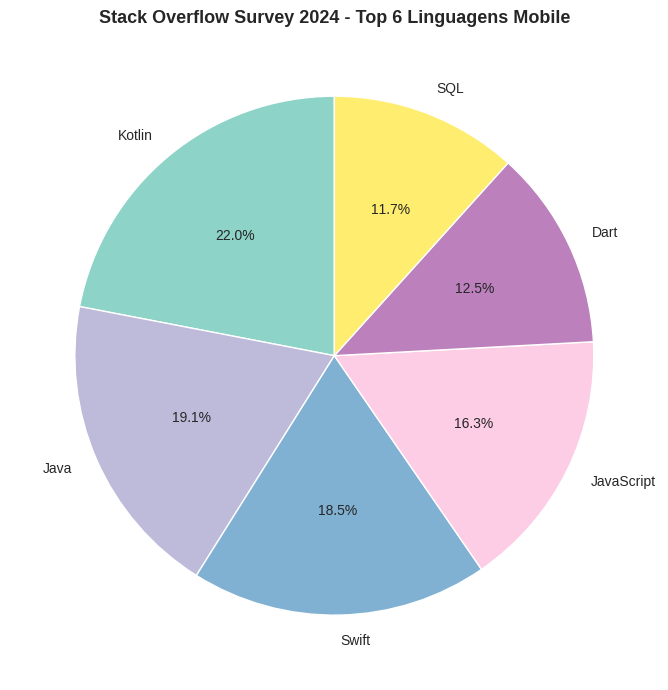

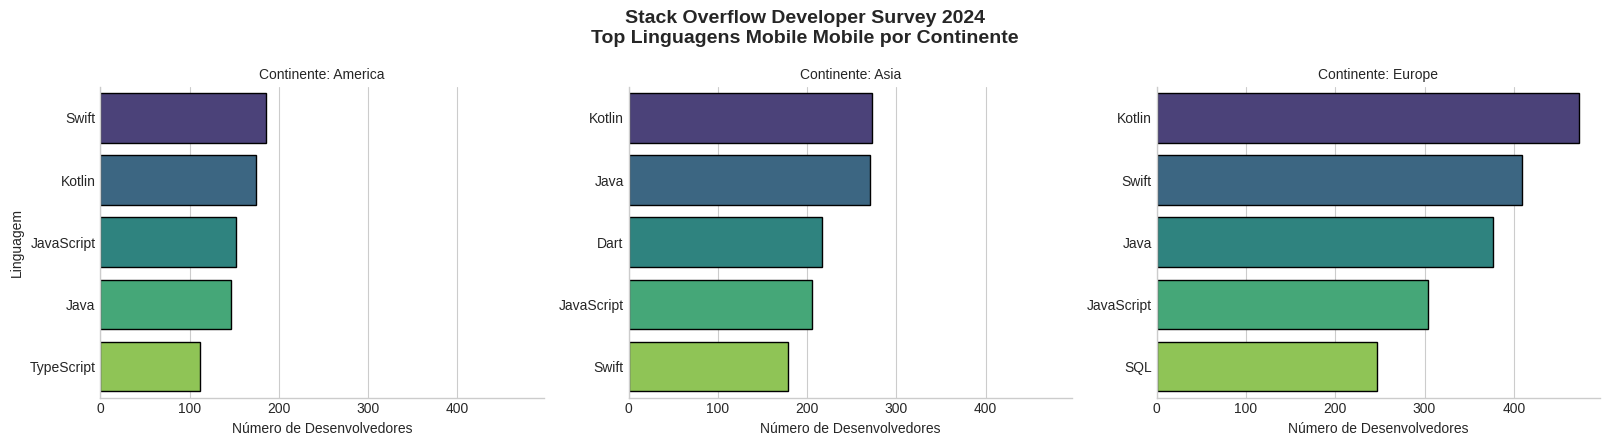

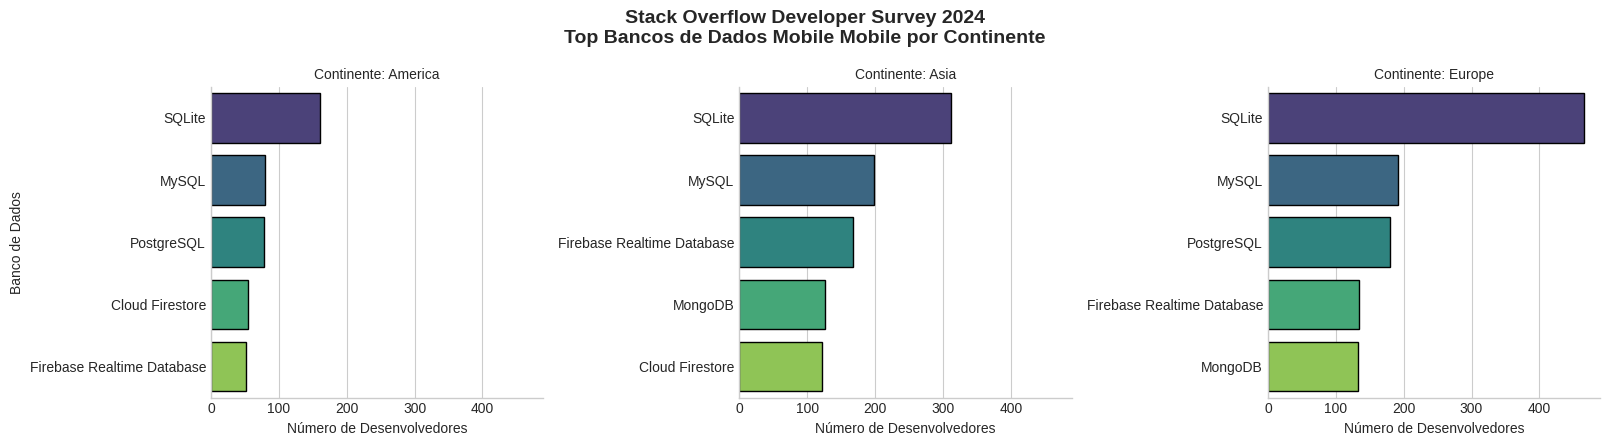

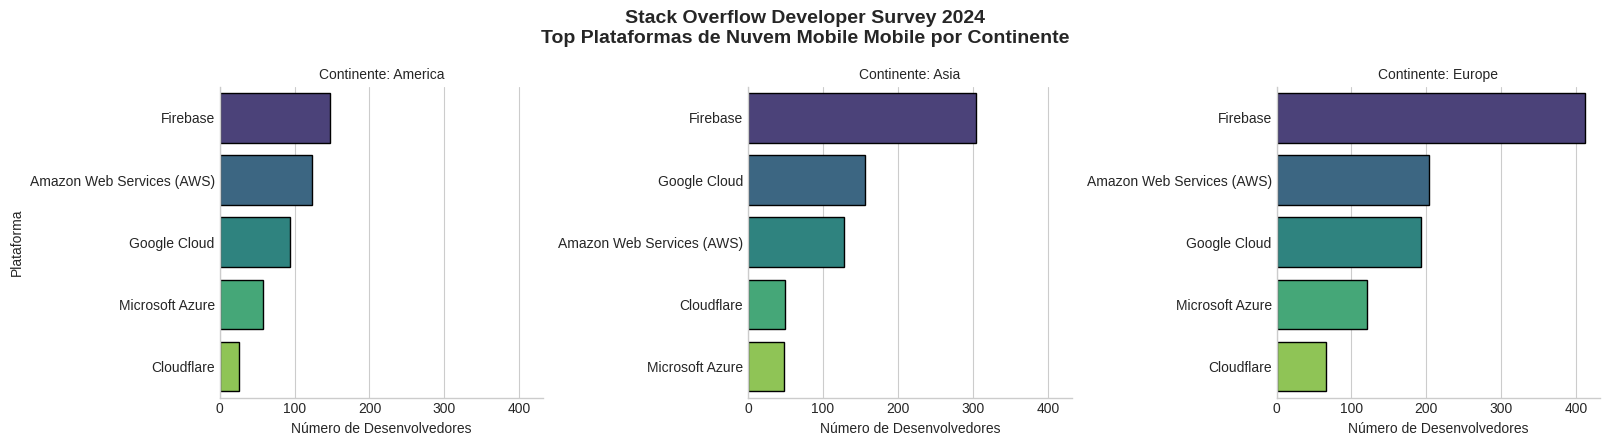

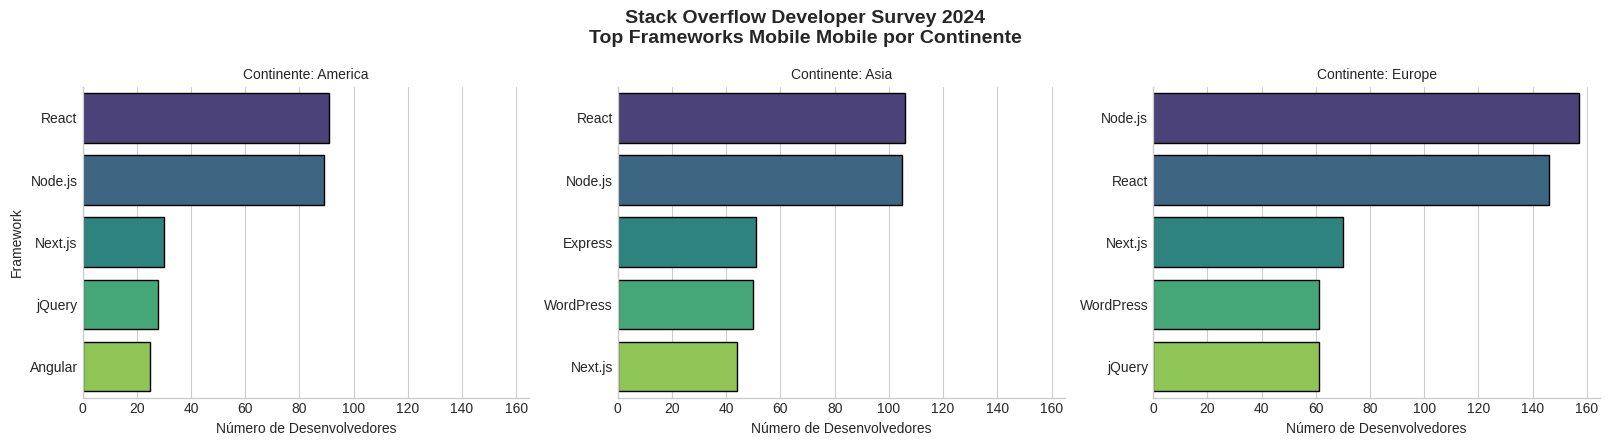


--- PROCESSANDO ANO 2025 ---
Dataset Mobile 2025 preparado. Total de registros: 1389


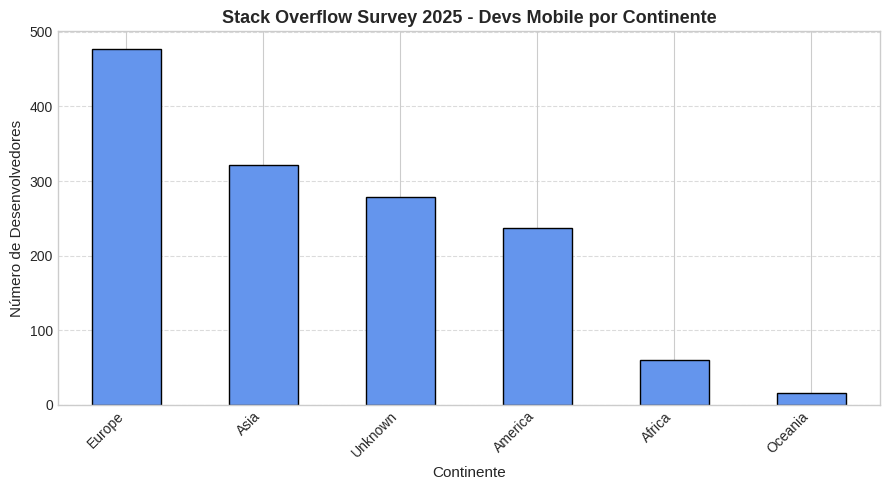

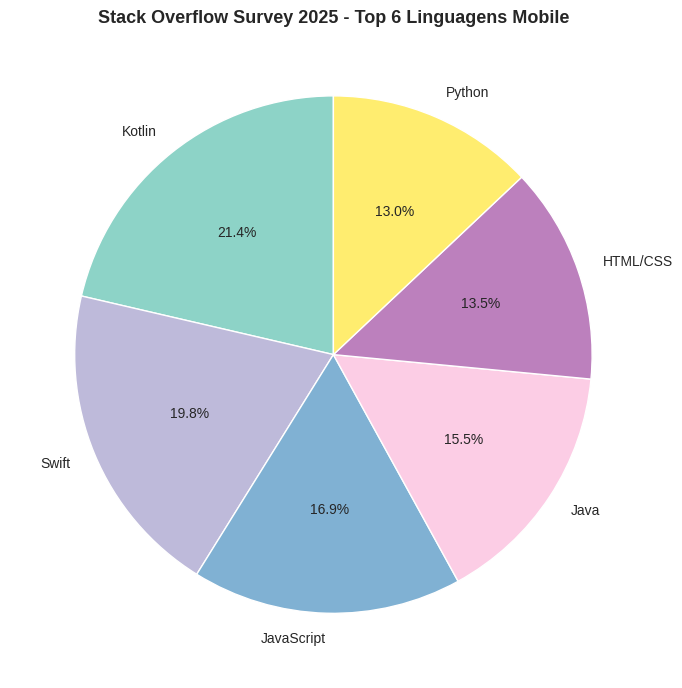

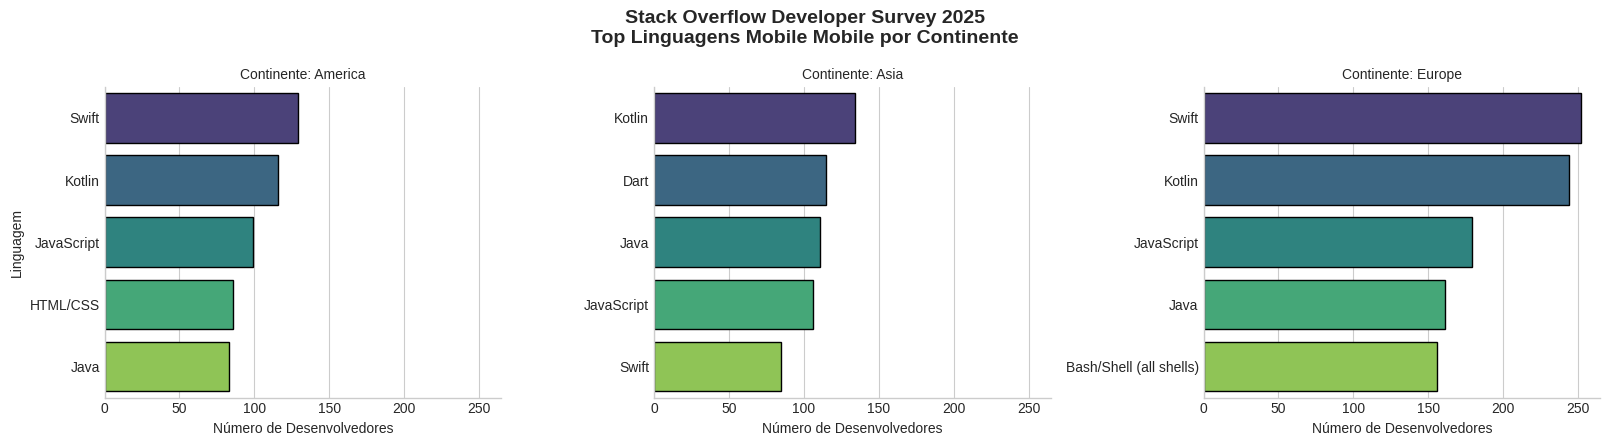

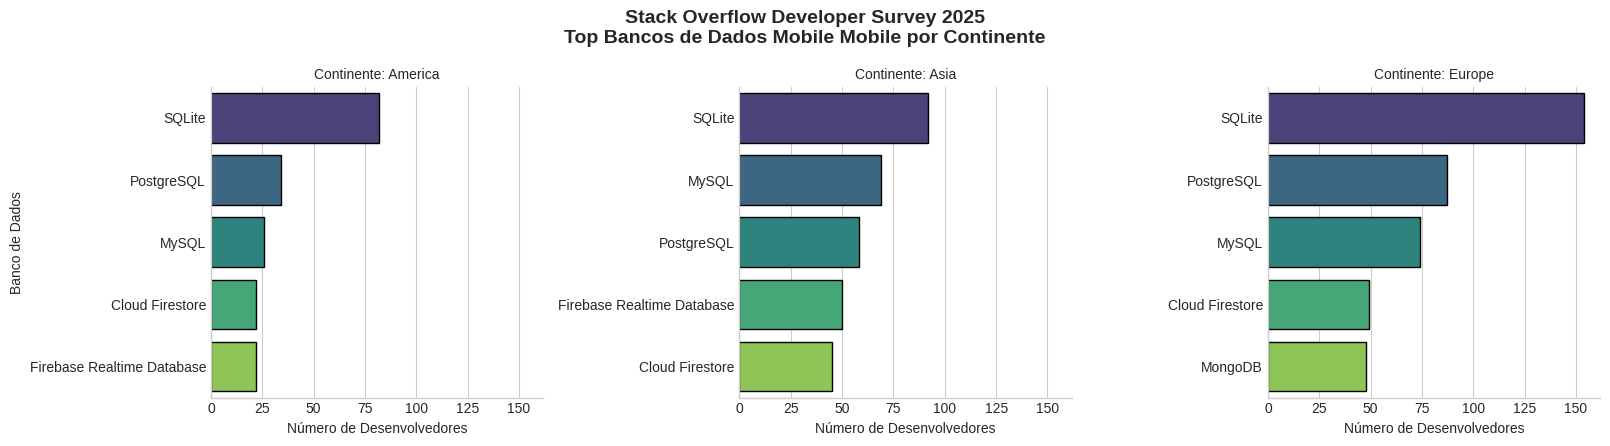

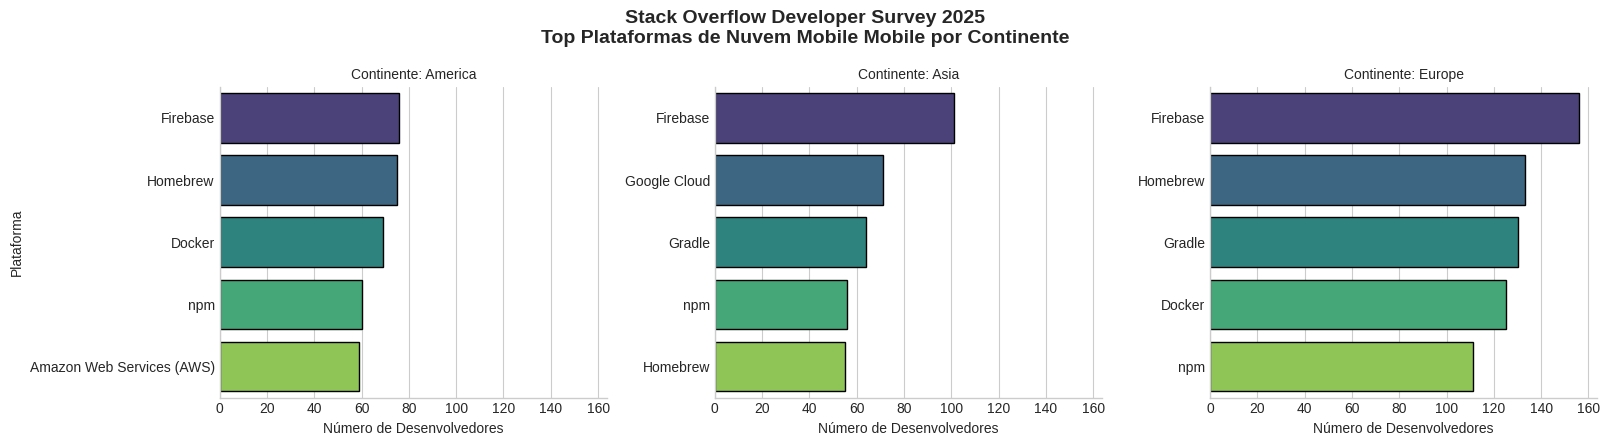

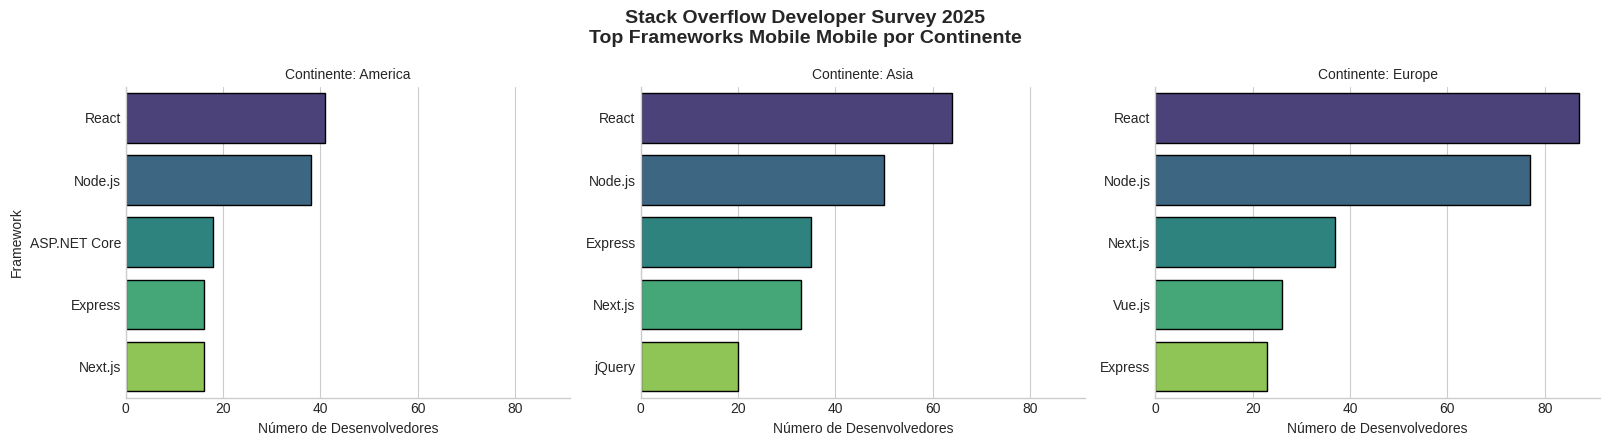

In [55]:
executar_pipeline_completo(df_2023, df_2024, df_2025)

## 2) Pesquise em 2 fontes confiáveis qual a participação de mercado (marketshare) dos dispositivos Android e iOS nos anos de 2025 e 2024, no Brasil, nos EUA, na Europa e na Ásia. Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



In [65]:
!kaggle datasets download -d datasets/sahirmaharajj/mobile-os-market-share

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [56]:
OUT = Path("resultado_market_share")
OUT.mkdir(exist_ok=True)

#codigos de endpoints publicos do statcounter
REGIOES = {
    "Brasil": "BR",
    "Estados Unidos": "US",
    "Europa": "EU",
    "Ásia": "AS",
}

ANOS = [2024, 2025]


In [57]:
def baixar_statcounter(region_code: str, start_year=2024, end_year=2025):
    #funcao pra baixar o grafico anual do stat counter
    params = {
        "device_hidden": "mobile",
        "statType_hidden": "os_combined",
        "region_hidden": region_code,
        "multi-device": "false",
        "csv": "1",
        "granularity": "yearly",
        "fromYear": str(start_year),
        "toYear": str(end_year),
    }

    url = "https://gs.statcounter.com/chart.php?" + urlencode(params)
    print(f"Baixando: {url}")

    r = requests.get(
        url,
        timeout=30,
        headers={"User-Agent": "Mozilla/5.0"}
    )
    r.raise_for_status()

    #endpoint deve retornar csv
    text = r.text
    if not text.strip():
        raise ValueError(f"Resposta vazia para {region_code}")

    df = pd.read_csv(io.StringIO(text))

    #normaliza colunas
    df.columns = [str(c).strip() for c in df.columns]

    return df, url


In [58]:
def localizar_colunas(df):
    """
    Tenta localizar automaticamente as colunas de ano, Android e iOS.
    """
    cols_lower = {c.lower(): c for c in df.columns}

    ano_col = next(
        (c for c in df.columns if "year" in c.lower() or "date" in c.lower()),
        df.columns[0]
    )

    android_col = next(
        (c for c in df.columns if "android" in c.lower()),
        None
    )
    ios_col = next(
        (c for c in df.columns if c.lower() == "ios" or "ios" in c.lower()),
        None
    )

    if android_col is None or ios_col is None:
        raise ValueError(
            "Não foi possível localizar as colunas Android/iOS. "
            f"Colunas encontradas: {list(df.columns)}"
        )

    return ano_col, android_col, ios_col



In [59]:
def preparar():
    partes = []
    urls = []

    for regiao, codigo in REGIOES.items():
        try:
            raw, url = baixar_statcounter(codigo, 2024, 2025)
            urls.append((regiao, url))

            ano_col, android_col, ios_col = localizar_colunas(raw)

            tmp = raw[[ano_col, android_col, ios_col]].copy()
            tmp.columns = ["Ano", "Android", "iOS"]

            # Converte valores como "83.2%" ou "83.2" para float.
            tmp["Ano"] = (
                tmp["Ano"]
                .astype(str)
                .str.extract(r"(20\d{2})")[0]
                .astype(int)
            )

            for c in ["Android", "iOS"]:
                tmp[c] = (
                    tmp[c]
                    .astype(str)
                    .str.replace("%", "", regex=False)
                    .str.replace(",", ".", regex=False)
                    .astype(float)
                )

            tmp = tmp[tmp["Ano"].isin(ANOS)].copy()
            tmp["Região"] = regiao
            partes.append(tmp)

        except Exception as e:
            print(f"[ERRO] {regiao}: {e}")

    if not partes:
        raise RuntimeError(
            "Nenhum dado foi baixado. "
            "Se o endpoint CSV do StatCounter estiver indisponível, "
            "baixe manualmente o CSV pelo botão 'Download Data (.csv)' "
            "na página do StatCounter e substitua a etapa de download."
        )

    df = pd.concat(partes, ignore_index=True)

    # Ordem das categorias.
    df = df[["Região", "Ano", "Android", "iOS"]]
    df = df.sort_values(["Região", "Ano"])

    return df, urls


In [60]:
def graficos(df):
    # 1) Gráfico de barras agrupadas
    long = df.melt(
        id_vars=["Região", "Ano"],
        value_vars=["Android", "iOS"],
        var_name="Sistema",
        value_name="Market Share (%)",
    )

    for ano in ANOS:
        d = long[long["Ano"] == ano]

        plt.figure(figsize=(10, 5))
        pivot = d.pivot(index="Região", columns="Sistema", values="Market Share (%)")
        pivot.plot(kind="bar", figsize=(10, 5))
        plt.title(f"Market share mobile: Android x iOS — {ano}")
        plt.ylabel("Participação (%)")
        plt.xlabel("")
        plt.xticks(rotation=0)
        plt.ylim(0, 100)
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(OUT / f"market_share_{ano}.png", dpi=200)
        plt.close()

    # 2) Evolução 2024 -> 2025
    for sistema in ["Android", "iOS"]:
        plt.figure(figsize=(10, 5))

        for regiao in df["Região"].unique():
            d = df[df["Região"] == regiao].sort_values("Ano")
            plt.plot(d["Ano"], d[sistema], marker="o", label=regiao)

        plt.title(f"Evolução do market share mobile — {sistema}")
        plt.ylabel("Participação (%)")
        plt.xlabel("Ano")
        plt.xticks(ANOS)
        plt.ylim(0, 100)
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT / f"evolucao_{sistema}.png", dpi=200)
        plt.close()



In [61]:
def resumo(df):
    # Diferença 2025 - 2024
    resumo_df = df.copy()
    resumo_df["Δ Android (p.p.)"] = (
        resumo_df.groupby("Região")["Android"].diff()
    )
    resumo_df["Δ iOS (p.p.)"] = (
        resumo_df.groupby("Região")["iOS"].diff()
    )

    resumo_df.to_csv(OUT / "dados_market_share.csv", index=False)

    print("\n=== DADOS ===")
    print(df.to_string(index=False))

    print("\n=== VARIAÇÃO 2025 - 2024 ===")
    print(
        resumo_df[[
            "Região", "Ano", "Android", "iOS",
            "Δ Android (p.p.)", "Δ iOS (p.p.)"
        ]].to_string(index=False)
    )



In [62]:

df, urls = preparar()
resumo(df)
graficos(df)

with open(OUT / "fontes.txt", "w", encoding="utf-8") as f:
    f.write("Fonte principal — StatCounter Global Stats\n")
    f.write("https://gs.statcounter.com/os-market-share/mobile\n\n")
    for regiao, url in urls:
        f.write(f"{regiao}: {url}\n")

    f.write("\nFonte secundária — Counterpoint Research\n")
    f.write("https://counterpointresearch.com/en/insights/global-smartphone-os-market-share\n")

print(f"\nArquivos salvos em: {OUT.resolve()}")


[ERRO] Brasil: name 'urlencode' is not defined
[ERRO] Estados Unidos: name 'urlencode' is not defined
[ERRO] Europa: name 'urlencode' is not defined
[ERRO] Ásia: name 'urlencode' is not defined


RuntimeError: Nenhum dado foi baixado. Se o endpoint CSV do StatCounter estiver indisponível, baixe manualmente o CSV pelo botão 'Download Data (.csv)' na página do StatCounter e substitua a etapa de download.

3) Cite 2 exemplos comerciais de alto grau de inovação tecnológica concebidos sobre o paradigma de computação móvel.
Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



4) Cite 5 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025. Descreva o nome, faturamento, quantidade de downloads e fontes.



5) Cite outras 10 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025 que não sejam no segmento de jogos. Descreva o nome, faturamento, quantidade de downloads e fontes.

6) Cite 5 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025 no segmento do projeto que você quer desenvolver ao término da disciplina. . Descreva o nome, faturamento, quantidade de downloads e fontes.


7) Qual o aparelho celular de maior poder de processamento comercializado no mundo e o seu preço?

8) Qual o aparelho celular de maior memória RAM comercializado no mundo e o seu preço?